# Phase 3: Feature Engineering

## Objectives

In this phase, you will:

1. Create new features from existing ones
2. Combine related features to capture domain knowledge
3. Extract temporal and categorical interactions
4. Engineer features specific to house pricing
5. Perform feature selection to identify most important features
6. Create an enhanced dataset with improved predictive power

## Instructions

Feature engineering is where domain knowledge meets data science. Think creatively about what makes a house valuable.

---
## Task 1: Import Libraries and Load Preprocessed Data

In [686]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [687]:
# TODO: Load preprocessed data from Phase 2
# - Read 'train_preprocessed.csv' and store in X
X = pd.read_csv('train_preprocessed.csv')
# - Read 'train_target.csv' and extract 'SalePrice' column into y
Y = pd.read_csv('train_target.csv')
df_original = pd.read_csv('train_cleaned.csv')
# - Read 'train_cleaned.csv' as df_original (for feature engineering with original values)

# TODO: Print shapes to verify data loaded correctly
print(X.shape)
print(Y.shape)
print(df_original.shape)

(1429, 194)
(1429, 1)
(1429, 69)


In [688]:
df_original.columns.tolist()

['MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'LotShape',
 'LandContour',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SaleType',
 'Sa

---
## Task 2: Understanding Feature Engineering

Feature engineering involves creating new features that better represent the underlying problem. For house prices, consider:

### Common Feature Engineering Techniques:

1. **Aggregation Features**: Combine related features
   - Total square footage = basement + 1st floor + 2nd floor
   - Total bathrooms = full baths + 0.5 * half baths

2. **Ratio Features**: Create meaningful ratios
   - Living area to lot area ratio
   - Price per square foot indicators

3. **Temporal Features**: Extract time-based information
   - Age of house = Year sold - Year built
   - Years since remodel

4. **Boolean Features**: Create indicator variables
   - Has second floor (yes/no)
   - Has basement (yes/no)
   - Is remodeled (yes/no)

5. **Polynomial Features**: Interactions between features
   - OverallQual * GrLivArea
   - Quality squared

6. **Binning**: Group continuous variables
   - Age categories (new, medium, old)
   - Price ranges

---
## Task 3: Create Aggregation Features

Combine related features to create more meaningful variables.

**Note:** Work with the original cleaned data for feature creation, as it has interpretable values.

In [689]:
# TODO: Create a working copy from original cleaned data
df_fe = df_original.copy()
df_fe.head()

# TODO: Print starting number of features

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,1Fam,2Story,7,5,2003,2003,Gable,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,Ex,Y,SBrkr,856,854,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,Feedr,1Fam,1Story,6,8,1976,1976,Gable,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,Ex,Y,SBrkr,1262,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,1Fam,2Story,7,5,2001,2002,Gable,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,Ex,Y,SBrkr,920,866,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,Norm,1Fam,2Story,7,5,1915,1970,Gable,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,Gd,Y,SBrkr,961,756,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,Norm,1Fam,2Story,8,5,2000,2000,Gable,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,Ex,Y,SBrkr,1145,1053,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000


### Step 3.1: Total Square Footage Features

In [690]:
# TODO: Create total square footage feature
# Combine basement, 1st floor, and 2nd floor areas
# Example: df_fe['TotalSF'] = df_fe['TotalBsmtSF'] + df_fe['1stFlrSF'] + df_fe['2ndFlrSF']
# Check if columns exist before combining
# Print confirmation when created
if 'TotalBsmtSF' in df_fe.columns and '1stFlrSF' in df_fe.columns and '2ndFlrSF' in df_fe.columns:
    df_fe['TotalSF'] = (
        df_fe['TotalBsmtSF']
        + df_fe['1stFlrSF']
        + df_fe['2ndFlrSF']
    )
    print("Feature 'TotalSF' created.")
else:
    print("One or more required columns are missing.")


Feature 'TotalSF' created.


### Step 3.2: Bathroom Features

In [691]:
# TODO: Create total bathrooms feature
# Formula: FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
# Check if columns exist before combining
if (
    'FullBath' in df_fe.columns and
    'HalfBath' in df_fe.columns and
    'BsmtFullBath' in df_fe.columns and
    'BsmtHalfBath' in df_fe.columns
):
    df_fe['TotalBathrooms'] = (
        df_fe['FullBath']
        + 0.5 * df_fe['HalfBath']
        + df_fe['BsmtFullBath']
        + 0.5 * df_fe['BsmtHalfBath']
    )
    print("Feature 'TotalBathrooms' created.")
else:
    print("One or more required bathroom columns are missing.")

Feature 'TotalBathrooms' created.


### Step 3.3: Porch and Outdoor Features

In [692]:
# TODO: Create total porch square footage
# Combine: OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch
# Check if columns exist before combining

df_fe['TotalPorchSF'] = 0

if 'OpenPorchSF' in df_fe.columns:
    df_fe['TotalPorchSF'] += df_fe['OpenPorchSF']

if 'EnclosedPorch' in df_fe.columns:
    df_fe['TotalPorchSF'] += df_fe['EnclosedPorch']

if '3SsnPorch' in df_fe.columns:
    df_fe['TotalPorchSF'] += df_fe['3SsnPorch']

if 'ScreenPorch' in df_fe.columns:
    df_fe['TotalPorchSF'] += df_fe['ScreenPorch']

print("TotalPorchSF feature created.")


TotalPorchSF feature created.


### Step 3.4: Your Custom Aggregation Features

Think about other meaningful combinations. What other groups of features make sense to combine?

In [693]:
# Finished basement square footage
df_fe['FinishedBsmtSF'] = df_fe['BsmtFinSF1'] + df_fe['BsmtFinSF2']

# Finished basement ratio (avoid division by zero)
df_fe['FinishedBsmtRatio'] = 0
mask = df_fe['TotalBsmtSF'] > 0
df_fe.loc[mask, 'FinishedBsmtRatio'] = (
    df_fe.loc[mask, 'FinishedBsmtSF'] / df_fe.loc[mask, 'TotalBsmtSF']
)

print("FinishedBsmtSF and FinishedBsmtRatio features created.")
df_fe[['BsmtFinSF1', 'BsmtFinSF2', 'TotalBsmtSF',
       'FinishedBsmtSF', 'FinishedBsmtRatio']].head()


FinishedBsmtSF and FinishedBsmtRatio features created.


/var/folders/9b/_svt9z5968vbrj3rtv2c5_qc0000gp/T/ipykernel_9503/86870769.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.82476636 0.77496038 0.52826087 ... 0.23871528 1.         0.89171975]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_fe.loc[mask, 'FinishedBsmtRatio'] = (


,BsmtFinSF1,BsmtFinSF2,TotalBsmtSF,FinishedBsmtSF,FinishedBsmtRatio
0,706,0,856,706,0.824766
1,978,0,1262,978,0.774960
2,486,0,920,486,0.528261
3,216,0,756,216,0.285714
4,655,0,1145,655,0.572052


---
## Task 4: Create Ratio and Proportion Features

Ratios can capture important relationships between features.

In [694]:
# Example: Living area to lot area ratio
# if 'GrLivArea' in df_fe.columns and 'LotArea' in df_fe.columns:
#     df_fe['LivingArea_to_LotArea'] = df_fe['GrLivArea'] / df_fe['LotArea']
#     print("Created: LivingArea_to_LotArea")

# Your ratio features here
# Ideas:
# - Basement ratio (basement area / total area)
# - Land slope to lot area
# - Garage area to living area

# Living area to lot area ratio
if 'GrLivArea' in df_fe.columns and 'LotArea' in df_fe.columns:
    df_fe['LivingArea_to_LotArea'] = df_fe['GrLivArea'] / df_fe['LotArea']
    print("Created: LivingArea_to_LotArea")

# Basement ratio (basement / total indoor area)
df_fe['Basement_to_TotalArea'] = 0
mask = (df_fe['TotalBsmtSF'] > 0) & (
    (df_fe['1stFlrSF'] + df_fe['2ndFlrSF'] + df_fe['TotalBsmtSF']) > 0
)

df_fe.loc[mask, 'Basement_to_TotalArea'] = (
    df_fe.loc[mask, 'TotalBsmtSF'] /
    (df_fe.loc[mask, '1stFlrSF'] + df_fe.loc[mask, '2ndFlrSF'] + df_fe.loc[mask, 'TotalBsmtSF'])
)

print("Created: Basement_to_TotalArea")

# Garage area to living area ratio
df_fe['Garage_to_LivingArea'] = 0
mask = (df_fe['GarageArea'] > 0) & (df_fe['GrLivArea'] > 0)


df_fe.loc[mask, 'Garage_to_LivingArea'] = (
    df_fe.loc[mask, 'GarageArea'] / df_fe.loc[mask, 'GrLivArea']
)


print("Created: Garage_to_LivingArea")


Created: LivingArea_to_LotArea
Created: Basement_to_TotalArea
Created: Garage_to_LivingArea


/var/folders/9b/_svt9z5968vbrj3rtv2c5_qc0000gp/T/ipykernel_9503/897966894.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.33359314 0.5        0.33998522 ... 0.32989691 0.5        0.5       ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_fe.loc[mask, 'Basement_to_TotalArea'] = (
/var/folders/9b/_svt9z5968vbrj3rtv2c5_qc0000gp/T/ipykernel_9503/897966894.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.32046784 0.36450079 0.34042553 ... 0.10769231 0.22263451 0.21974522]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_fe.loc[mask, 'Garage_to_LivingArea'] = (


---
## Task 5: Create Temporal Features

Extract time-related features that might affect house prices.

In [695]:
# Years since remodel
if 'YrSold' in df_fe.columns and 'YearRemodAdd' in df_fe.columns:
    df_fe['YearsSinceRemodel'] = df_fe['YrSold'] - df_fe['YearRemodAdd']
    print("Created: YearsSinceRemodel")

# Was remodeled (binary)
if 'YearRemodAdd' in df_fe.columns and 'YearBuilt' in df_fe.columns:
    df_fe['WasRemodeled'] = (df_fe['YearRemodAdd'] > df_fe['YearBuilt']).astype(int)
    print("Created: WasRemodeled")


# Garage age at sale
df_fe['GarageAge'] = 0
if 'GarageYrBlt' in df_fe.columns and 'YrSold' in df_fe.columns:
    mask = df_fe['GarageYrBlt'] > 0
    df_fe.loc[mask, 'GarageAge'] = df_fe.loc[mask, 'YrSold'] - df_fe.loc[mask, 'GarageYrBlt']
    print("Created: GarageAge")

# Is newly built (within 5 years)
if 'HouseAge' in df_fe.columns:
    df_fe['IsNewHouse'] = (df_fe['HouseAge'] <= 5).astype(int)
    print("Created: IsNewHouse")


Created: YearsSinceRemodel
Created: WasRemodeled
Created: GarageAge


---
## Task 6: Create Boolean/Indicator Features

Binary features can be very informative.

In [696]:
# Example: Has second floor
if '2ndFlrSF' in df_fe.columns:
    df_fe['HasSecondFloor'] = (df_fe['2ndFlrSF'] > 0).astype(int)
    print("Created: HasSecondFloor")

# Has basement
df_fe['HasBasement'] = (df_fe['TotalBsmtSF'] > 0).astype(int)
print("Created: HasBasement")

# Has garage
df_fe['HasGarage'] = (df_fe['GarageArea'] > 0).astype(int)
print("Created: HasGarage")

# Has fireplace
df_fe['HasFireplace'] = (df_fe['Fireplaces'] > 0).astype(int)
print("Created: HasFireplace")

# Has pool
df_fe['HasPool'] = (df_fe['PoolArea'] > 0).astype(int)
print("Created: HasPool")

# Has porch (any porch type)
porch_cols = ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']
existing_porch_cols = [col for col in porch_cols if col in df_fe.columns]

df_fe['HasPorch'] = 0
if existing_porch_cols:
    df_fe['HasPorch'] = (df_fe[existing_porch_cols].sum(axis=1) > 0).astype(int)
print("Created: HasPorch")

# Is remodeled
df_fe['IsRemodeled'] = (df_fe['YearRemodAdd'] != df_fe['YearBuilt']).astype(int)
print("Created: IsRemodeled")


Created: HasSecondFloor
Created: HasBasement
Created: HasGarage
Created: HasFireplace
Created: HasPool
Created: HasPorch
Created: IsRemodeled


---
## Task 7: Create Interaction Features

Sometimes the interaction between features is more important than individual features.

In [697]:
# Example: Overall quality * living area
# High quality homes with large area are especially valuable
if 'OverallQual' in df_fe.columns and 'GrLivArea' in df_fe.columns:
    df_fe['Quality_x_Area'] = df_fe['OverallQual'] * df_fe['GrLivArea']
    print("Created: Quality_x_Area")

# Quality × Condition
if 'OverallQual' in df_fe.columns and 'OverallCond' in df_fe.columns:
    df_fe['Quality_x_Condition'] = df_fe['OverallQual'] * df_fe['OverallCond']
    print("Created: Quality_x_Condition")

# Quality × Living Area
if 'OverallQual' in df_fe.columns and 'GrLivArea' in df_fe.columns:
    df_fe['Quality_x_Area'] = df_fe['OverallQual'] * df_fe['GrLivArea']
    print("Created: Quality_x_Area")

# Bathrooms × Bedrooms
if 'TotalBathrooms' in df_fe.columns and 'BedroomAbvGr' in df_fe.columns:
    df_fe['Baths_x_Bedrooms'] = df_fe['TotalBathrooms'] * df_fe['BedroomAbvGr']
    print("Created: Baths_x_Bedrooms")

# Garage capacity × Living Area
if 'GarageCars' in df_fe.columns and 'GrLivArea' in df_fe.columns:
    df_fe['GarageCars_x_Area'] = df_fe['GarageCars'] * df_fe['GrLivArea']
    print("Created: GarageCars_x_Area")


Created: Quality_x_Area
Created: Quality_x_Condition
Created: Quality_x_Area
Created: Baths_x_Bedrooms
Created: GarageCars_x_Area


---
## Task 8: Create Polynomial Features (Optional)

Squared or higher-order terms can capture non-linear relationships.

In [698]:
# Example: Quality squared
if 'OverallQual' in df_fe.columns:
    df_fe['OverallQual_Squared'] = df_fe['OverallQual'] ** 2
    print("Created: OverallQual_Squared")

# Your polynomial features here (be selective, don't overdo it)
# Usually apply to features with strong correlations to target

Created: OverallQual_Squared


---
## Task 9: Feature Summary and Analysis

Review all the features you've created.

In [699]:
# TODO: Identify new features created
# - Compare columns in df_fe vs df_original
# - Use list comprehension to find new columns
# - Store in 'new_features' variable

# TODO: Print feature counts
# - Original feature count (from df_original.columns)
# - New features created (length of new_features list)
# - Total features (from df_fe.columns)

# TODO: Print list of all new features with numbering

# Identify new features created
new_features = [col for col in df_fe.columns if col not in df_original.columns]

# Print feature counts
print(f"Original feature count: {len(df_original.columns)}")
print(f"New features created: {len(new_features)}")
print(f"Total features after feature engineering: {len(df_fe.columns)}")

# Print list of new features with numbering
print("\nNew engineered features:")
for i, feature in enumerate(new_features, start=1):
    print(f"{i}. {feature}")


Original feature count: 69
New features created: 23
Total features after feature engineering: 92

New engineered features:
1. TotalSF
2. TotalBathrooms
3. TotalPorchSF
4. FinishedBsmtSF
5. FinishedBsmtRatio
6. LivingArea_to_LotArea
7. Basement_to_TotalArea
8. Garage_to_LivingArea
9. YearsSinceRemodel
10. WasRemodeled
11. GarageAge
12. HasSecondFloor
13. HasBasement
14. HasGarage
15. HasFireplace
16. HasPool
17. HasPorch
18. IsRemodeled
19. Quality_x_Area
20. Quality_x_Condition
21. Baths_x_Bedrooms
22. GarageCars_x_Area
23. OverallQual_Squared


In [700]:
# Display statistics of new engineered features
if new_features:
    print("Descriptive statistics for new engineered features:")
    display(df_fe[new_features].describe())
else:
    print("No new engineered features found.")


Descriptive statistics for new engineered features:


,TotalSF,TotalBathrooms,TotalPorchSF,FinishedBsmtSF,FinishedBsmtRatio,LivingArea_to_LotArea,Basement_to_TotalArea,Garage_to_LivingArea,YearsSinceRemodel,WasRemodeled,GarageAge,HasSecondFloor,HasBasement,HasGarage,HasFireplace,HasPool,HasPorch,IsRemodeled,Quality_x_Area,Quality_x_Condition,Baths_x_Bedrooms,GarageCars_x_Area,OverallQual_Squared
count,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000
mean,2521.249125,2.185794,85.640308,469.806858,0.432281,0.182198,0.406832,0.324542,23.103569,0.473758,29.328901,0.432470,0.974108,0.943317,0.517845,0.003499,0.682295,0.473758,9424.869839,33.713786,6.399580,2781.363891,38.600420
std,720.640498,0.767157,104.083943,437.618884,0.363985,0.111892,0.108011,0.149231,20.690372,0.499486,24.053183,0.495592,0.158869,0.231317,0.499856,0.059069,0.465747,0.499486,4599.425009,9.130701,3.222094,1766.149042,16.866605
min,334.000000,1.000000,0.000000,0.000000,0.000000,0.030476,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,1.000000,0.000000,0.000000,1.000000
25%,1999.000000,2.000000,0.000000,0.000000,0.000000,0.119835,0.333333,0.247191,4.000000,0.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,5748.000000,30.000000,4.000000,1396.000000,25.000000
50%,2456.000000,2.000000,48.000000,454.000000,0.500000,0.156393,0.441417,0.312590,15.000000,0.000000,28.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,8736.000000,35.000000,6.000000,2656.000000,36.000000
75%,2973.000000,2.500000,134.000000,777.000000,0.763056,0.195973,0.500000,0.403846,41.000000,1.000000,46.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,12019.000000,40.000000,8.000000,3584.000000,49.000000
max,5271.000000,6.000000,1027.000000,1880.000000,1.000000,0.945385,0.561317,1.395973,60.000000,1.000000,107.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,36080.000000,90.000000,27.000000,10824.000000,100.000000


---
## Task 10: Analyze Feature Correlations with Target

Evaluate which features (old and new) correlate strongest with SalePrice.

In [701]:
# TODO: Add target variable for correlation analysis
# - Add 'SalePrice' column from df_original to df_fe

# TODO: Calculate correlations with target
# - Select only numerical columns using select_dtypes
# - Calculate correlation matrix using .corr()
# - Extract 'SalePrice' column and sort in descending order
# - Store in 'correlations' variable

# TODO: Print top 20 features most correlated with SalePrice
# TODO: Print bottom 10 features (negative or weak correlation)
# Add target variable to feature-engineered dataframe
df_fe['SalePrice'] = df_original['SalePrice']

# Select only numerical columns
numeric_df = df_fe.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Extract correlations with SalePrice and sort
correlations = corr_matrix['SalePrice'].sort_values(ascending=False)

# Print top 20 positively correlated features
print("Top 20 features most correlated with SalePrice:")
print(correlations.head(20))

# Print bottom 10 features (weak or negative correlation)
print("\nBottom 10 features (weak or negative correlation):")
print(correlations.tail(10))


Top 20 features most correlated with SalePrice:
SalePrice              1.000000
Quality_x_Area         0.861592
OverallQual_Squared    0.832748
TotalSF                0.816656
OverallQual            0.811216
GarageCars_x_Area      0.811032
GrLivArea              0.711127
GarageCars             0.657341
GarageArea             0.643106
TotalBathrooms         0.632273
TotalBsmtSF            0.623101
1stFlrSF               0.603729
Quality_x_Condition    0.574832
FullBath               0.563282
YearBuilt              0.554461
YearRemodAdd           0.541672
Baths_x_Bedrooms       0.521144
TotRmsAbvGrd           0.518788
GarageYrBlt            0.497430
HasFireplace           0.485450
Name: SalePrice, dtype: float64

Bottom 10 features (weak or negative correlation):
BsmtHalfBath        -0.033843
YrSold              -0.033853
WasRemodeled        -0.049460
IsRemodeled         -0.049460
OverallCond         -0.073717
MSSubClass          -0.075941
EnclosedPorch       -0.142274
KitchenAbvGr      

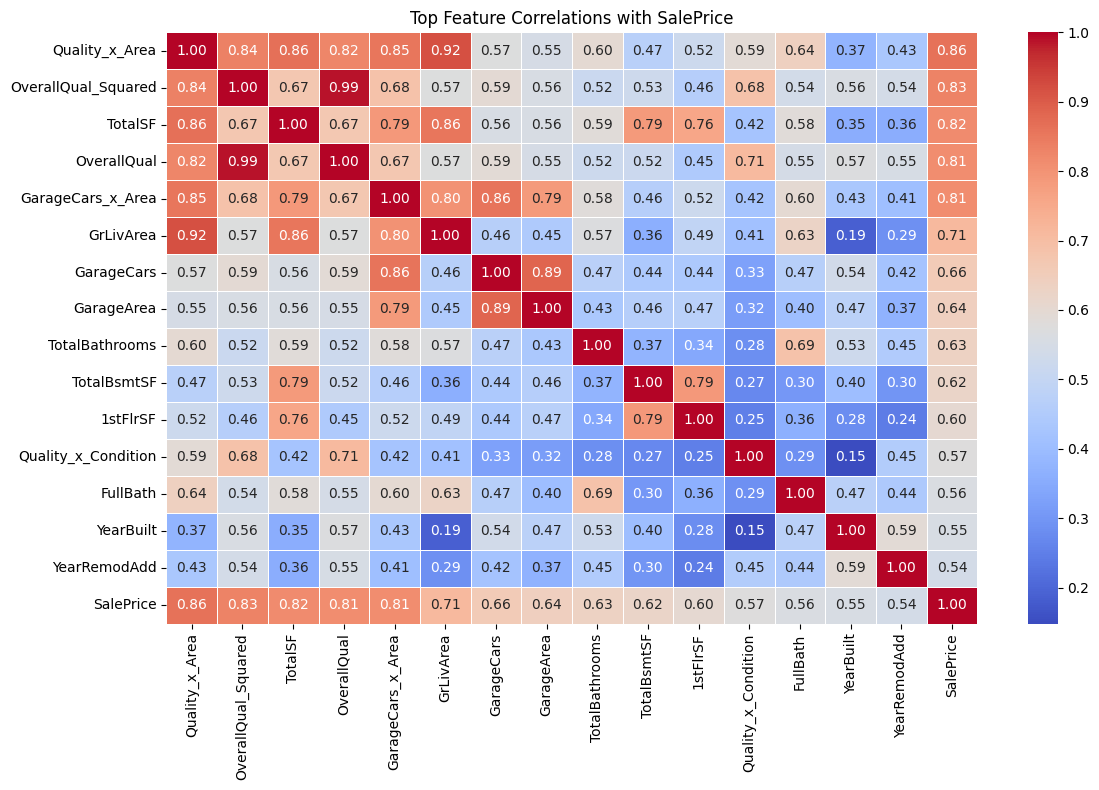

In [702]:
# TODO: Visualize top correlations
# - Get top 15 features from correlations
# - Remove 'SalePrice' itself from the list
# - Create correlation matrix of top features with SalePrice
# - Create heatmap using seaborn (figsize=(12, 8))
# - Use coolwarm colormap with annotations
# - Add title and display the plot
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 15 correlated features (excluding SalePrice itself)
top_features = correlations.drop('SalePrice').head(15).index.tolist()

# Create correlation matrix for selected features + SalePrice
corr_top = df_fe[top_features + ['SalePrice']].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_top,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Top Feature Correlations with SalePrice')
plt.tight_layout()
plt.show()


### Analysis: Which New Features are Most Valuable?

Identify which of your newly created features show strong correlation with SalePrice.

Correlations of new engineered features with SalePrice:
Quality_x_Area           0.861592
OverallQual_Squared      0.832748
TotalSF                  0.816656
GarageCars_x_Area        0.811032
TotalBathrooms           0.632273
Quality_x_Condition      0.574832
Baths_x_Bedrooms         0.521144
HasFireplace             0.485450
FinishedBsmtSF           0.331903
HasPorch                 0.308405
HasGarage                0.255065
TotalPorchSF             0.201334
HasBasement              0.164249
HasSecondFloor           0.145701
Garage_to_LivingArea     0.117816
FinishedBsmtRatio        0.116116
Basement_to_TotalArea    0.040965
HasPool                  0.038284
LivingArea_to_LotArea    0.013219
WasRemodeled            -0.049460
IsRemodeled             -0.049460
GarageAge               -0.498450
YearsSinceRemodel       -0.543949
Name: SalePrice, dtype: float64


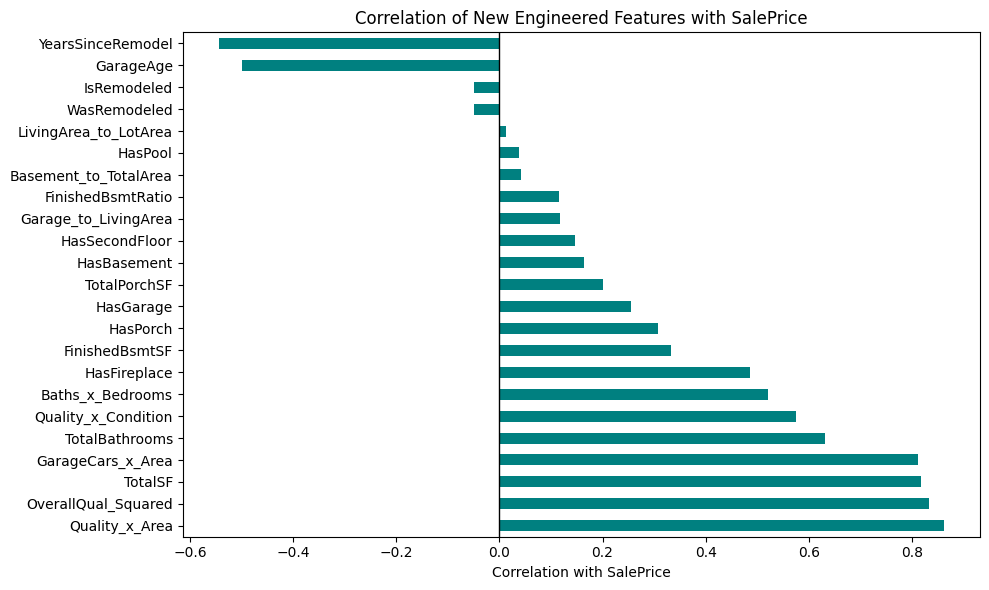

In [703]:
# TODO: Analyze new features specifically
# - Check if new_features list is not empty
# - Get correlations for only new features from correlations series
# - Sort values in descending order
# - Print correlations of new features with SalePrice

# TODO: Visualize new feature correlations
# - Create horizontal bar plot (figsize=(10, 6))
# - Use color='teal'
# - Add xlabel, title
# - Add vertical line at x=0 to show positive/negative correlations
# - Display the plot
import matplotlib.pyplot as plt

# Analyze new features specifically
if new_features:
    new_feature_corr = correlations[new_features].sort_values(ascending=False)

    print("Correlations of new engineered features with SalePrice:")
    print(new_feature_corr)

    # Visualize new feature correlations
    plt.figure(figsize=(10, 6))
    new_feature_corr.plot(kind='barh', color='teal')
    plt.axvline(0, color='black', linewidth=1)
    plt.xlabel('Correlation with SalePrice')
    plt.title('Correlation of New Engineered Features with SalePrice')
    plt.tight_layout()
    plt.show()
else:
    print("No new engineered features to analyze.")


---
## Task 11: Feature Selection (Optional)

Consider removing features with:
- Very low correlation with target (< 0.05)
- High correlation with other features (multicollinearity)
- Little variance

In [704]:
# Features selected for removal after analysis
features_to_remove = [
    'LivingArea_to_LotArea',
    'MiscVal',
    'BsmtFinSF2',
    'BsmtHalfBath',
    'YrSold',
    'PoolArea',
    'WasRemodeled'
]

# Drop only features that exist
features_to_remove = [f for f in features_to_remove if f in df_fe.columns]

df_fe.drop(columns=features_to_remove, inplace=True)

print(f"Dropped {len(features_to_remove)} low-importance or redundant features:")
for f in features_to_remove:
    print(f"- {f}")


Dropped 7 low-importance or redundant features:
- LivingArea_to_LotArea
- MiscVal
- BsmtFinSF2
- BsmtHalfBath
- YrSold
- PoolArea
- WasRemodeled


In [705]:
# TODO: Check for multicollinearity among top features
# - Get top 20 features from correlations
# - Remove 'SalePrice' if present
# - Create correlation matrix for these features

# TODO: Find highly correlated pairs (>0.8)
# - Loop through correlation matrix
# - Find pairs with |correlation| > 0.8
# - Store pairs with their correlation values
# - Print results

# High correlation between features might indicate redundancy
# Consider removing one from highly correlated pairs

# ---- Multicollinearity inspection ----

# Get top 20 correlated features (excluding SalePrice)
top_20_features = correlations.drop('SalePrice').head(20).index.tolist()# 
print(top_20_features)

# Create correlation matrix for top features
top_corr_matrix = df_fe[top_20_features].corr()

# Find highly correlated feature pairs
high_corr_pairs = []

threshold = 0.8

for i in range(len(top_corr_matrix.columns)):
    for j in range(i + 1, len(top_corr_matrix.columns)):
        corr_value = top_corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            feature_1 = top_corr_matrix.columns[i]
            feature_2 = top_corr_matrix.columns[j]
            high_corr_pairs.append((feature_1, feature_2, corr_value))


# Print results
print(f"Correlation threshold for multicollinearity: {threshold}")
print(f"Number of highly correlated feature pairs: {len(high_corr_pairs)}\n")

if high_corr_pairs:
    print("Highly correlated feature pairs (|corr| > 0.8):")
    for f1, f2, corr in high_corr_pairs:
        print(f"{f1}  <->  {f2} : corr = {corr:.3f}")
else:
    print("No highly correlated feature pairs found.")


['Quality_x_Area', 'OverallQual_Squared', 'TotalSF', 'OverallQual', 'GarageCars_x_Area', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBathrooms', 'TotalBsmtSF', '1stFlrSF', 'Quality_x_Condition', 'FullBath', 'YearBuilt', 'YearRemodAdd', 'Baths_x_Bedrooms', 'TotRmsAbvGrd', 'GarageYrBlt', 'HasFireplace', 'Fireplaces']
Correlation threshold for multicollinearity: 0.8
Number of highly correlated feature pairs: 13

Highly correlated feature pairs (|corr| > 0.8):
Quality_x_Area  <->  OverallQual_Squared : corr = 0.835
Quality_x_Area  <->  TotalSF : corr = 0.864
Quality_x_Area  <->  OverallQual : corr = 0.825
Quality_x_Area  <->  GarageCars_x_Area : corr = 0.854
Quality_x_Area  <->  GrLivArea : corr = 0.918
OverallQual_Squared  <->  OverallQual : corr = 0.988
TotalSF  <->  GrLivArea : corr = 0.857
GarageCars_x_Area  <->  GrLivArea : corr = 0.803
GarageCars_x_Area  <->  GarageCars : corr = 0.859
GrLivArea  <->  TotRmsAbvGrd : corr = 0.831
GarageCars  <->  GarageArea : corr = 0.887
TotalBathr

---
## Task 12: Apply Feature Engineering to Test Set

Create the exact same features for the test dataset.

In [706]:
# Load test data (you should have a cleaned version from Phase 1)
# test_df = pd.read_csv('test_cleaned.csv')

# Apply ALL the same feature engineering steps
# This is critical for model predictions later

# Your code here
# ===============================
# Feature Engineering on Test Set
# ===============================

# Load cleaned test data
# Prefer cleaned test if available
try:
    test_df = pd.read_csv('test_cleaned.csv')
    print('Loaded test_cleaned.csv')
except FileNotFoundError:
    test_df = pd.read_csv('test.csv')
    print('Loaded test.csv')

# Create feature engineering copy
test_fe = test_df.copy()

# ---- Size & Area Features ----
test_fe['TotalSF'] = (
    test_fe['TotalBsmtSF'] +
    test_fe['1stFlrSF'] +
    test_fe['2ndFlrSF']
)

test_fe['FinishedBsmtSF'] = test_fe['BsmtFinSF1'] + test_fe['BsmtFinSF2']

test_fe['FinishedBsmtRatio'] = 0
mask = test_fe['TotalBsmtSF'] > 0
test_fe.loc[mask, 'FinishedBsmtRatio'] = (
    test_fe.loc[mask, 'FinishedBsmtSF'] / test_fe.loc[mask, 'TotalBsmtSF']
)

# ---- Bathroom Feature ----
test_fe['TotalBathrooms'] = (
    test_fe['FullBath'] +
    0.5 * test_fe['HalfBath'] +
    test_fe['BsmtFullBath'] +
    0.5 * test_fe['BsmtHalfBath']
)

# ---- Porch Feature ----
test_fe['TotalPorchSF'] = 0
for col in ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']:
    if col in test_fe.columns:
        test_fe['TotalPorchSF'] += test_fe[col]

# ---- Ratio Features ----
test_fe['LivingArea_to_LotArea'] = test_fe['GrLivArea'] / test_fe['LotArea']

test_fe['Basement_to_TotalArea'] = 0
mask = (test_fe['TotalBsmtSF'] > 0) & (test_fe['TotalSF'] > 0)
test_fe.loc[mask, 'Basement_to_TotalArea'] = (
    test_fe.loc[mask, 'TotalBsmtSF'] / test_fe.loc[mask, 'TotalSF']
)

test_fe['Garage_to_LivingArea'] = 0
mask = (test_fe['GarageArea'] > 0) & (test_fe['GrLivArea'] > 0)
test_fe.loc[mask, 'Garage_to_LivingArea'] = (
    test_fe.loc[mask, 'GarageArea'] / test_fe.loc[mask, 'GrLivArea']
)

# ---- Temporal Features ----
test_fe['HouseAge'] = test_fe['YrSold'] - test_fe['YearBuilt']
test_fe['YearsSinceRemodel'] = test_fe['YrSold'] - test_fe['YearRemodAdd']

test_fe['GarageAge'] = 0
mask = test_fe['GarageYrBlt'] > 0
test_fe.loc[mask, 'GarageAge'] = (
    test_fe.loc[mask, 'YrSold'] - test_fe.loc[mask, 'GarageYrBlt']
)

test_fe['IsNewHouse'] = (test_fe['HouseAge'] <= 5).astype(int)

# ---- Boolean Features ----
test_fe['HasBasement'] = (test_fe['TotalBsmtSF'] > 0).astype(int)
test_fe['HasGarage'] = (test_fe['GarageArea'] > 0).astype(int)
test_fe['HasFireplace'] = (test_fe['Fireplaces'] > 0).astype(int)
test_fe['HasPool'] = (test_fe['PoolArea'] > 0).astype(int)

porch_cols = [c for c in ['OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch'] if c in test_fe.columns]
test_fe['HasPorch'] = (test_fe[porch_cols].sum(axis=1) > 0).astype(int)

test_fe['IsRemodeled'] = (test_fe['YearRemodAdd'] != test_fe['YearBuilt']).astype(int)

# ---- Interaction Features ----
test_fe['Quality_x_Condition'] = test_fe['OverallQual'] * test_fe['OverallCond']
test_fe['Quality_x_Area'] = test_fe['OverallQual'] * test_fe['GrLivArea']
test_fe['Baths_x_Bedrooms'] = test_fe['TotalBathrooms'] * test_fe['BedroomAbvGr']
test_fe['GarageCars_x_Area'] = test_fe['GarageCars'] * test_fe['GrLivArea']

# ---- Final Check ----
print("Test feature engineering completed.")
print("Final shape:", test_fe.shape)
print("Total missing values:", test_fe.isnull().sum().sum())


Loaded test_cleaned.csv
Test feature engineering completed.
Final shape: (1459, 91)
Total missing values: 1267


/var/folders/9b/_svt9z5968vbrj3rtv2c5_qc0000gp/T/ipykernel_9503/2577186376.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.69387755 0.69450715 0.85237069 ... 1.         0.36951754 0.76104418]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_fe.loc[mask, 'FinishedBsmtRatio'] = (
/var/folders/9b/_svt9z5968vbrj3rtv2c5_qc0000gp/T/ipykernel_9503/2577186376.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.49606299 0.5        0.3629253  ... 0.5        0.48459086 0.33244326]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_fe.loc[mask, 'Basement_to_TotalArea'] = (
/var/folders/9b/_svt9z5968vbrj3rtv2c5_qc0000gp/T/ipykernel_9503/2577186376.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise 

In [707]:
if 'SalePrice' in df_fe.columns:
    print("Error: 'SalePrice' column still present in final dataset.")
else:
    print("'SalePrice' column successfully removed from final dataset.")

Error: 'SalePrice' column still present in final dataset.


---
## Task 13: Final Feature Engineering Summary

Document all transformations for reproducibility.

In [708]:
# TODO: Remove target before saving
# - Drop 'SalePrice' column from df_fe
# - Store in df_fe_final

# TODO: Print Feature Engineering Summary
# - Original feature count (subtract 1 for SalePrice)
# - New features created (length of new_features)
# - Total features in final dataset
# - Total samples (rows)
# - Count of missing values
# ===============================
# Task 13: Final Feature Engineering Summary
# ===============================

# make this line coorect df_fe = df_fe_final
df_fe_final = df_fe

    



# Print Feature Engineering Summary
print("Final Feature Engineering Summary")
print("-" * 35)

print(f"Original feature count (excluding SalePrice): {len(df_original.columns) - 1}")
print(f"New features created: {len(new_features)}")
print(f"Total features in final dataset: {df_fe_final.shape[1]}")
print(f"Total samples (rows): {df_fe_final.shape[0]}")
print(f"Total missing values: {df_fe_final.isnull().sum().sum()}")


Final Feature Engineering Summary
-----------------------------------
Original feature count (excluding SalePrice): 68
New features created: 23
Total features in final dataset: 85
Total samples (rows): 1429
Total missing values: 1199


In [709]:
# TODO: Save feature-engineered dataset
# - Save df_fe_final to 'train_feature_engineered.csv'
# - Use index=False parameter
# - Print confirmation message

# TODO: Save list of new features for documentation
# - Open file 'new_features_list.txt' for writing
# - Write header "New Features Created:"
# - Write separator line
# - Write each feature name with numbering
# - Print confirmation message
# ===============================
# Save Feature-Engineered Outputs
# ===============================

# Save feature-engineered training dataset
df_fe_final.to_csv('train_feature_engineered.csv', index=False)
print("Saved feature-engineered dataset as 'train_feature_engineered.csv'")

# Save list of new features for documentation
with open('new_features_list.txt', 'w') as f:
    f.write("New Features Created:\n")
    f.write("-" * 25 + "\n")
    for i, feature in enumerate(new_features, start=1):
        f.write(f"{i}. {feature}\n")

print("Saved new features list as 'new_features_list.txt'")


Saved feature-engineered dataset as 'train_feature_engineered.csv'
Saved new features list as 'new_features_list.txt'


---
## Summary and Reflection

### What You Accomplished:

1. Created aggregation features by combining related variables
2. Developed ratio and proportion features
3. Extracted temporal features (age, renovation status)
4. Created boolean indicator features
5. Engineered interaction and polynomial features
6. Analyzed correlations of new features with target
7. Assessed feature importance and multicollinearity
8. Applied same transformations to test data

### Key Questions for Reflection:

1. How many new features did you create?
2. Which new features have the highest correlation with SalePrice?
3. Did any of your engineered features outperform existing features?
4. How did you handle multicollinearity among features?
5. What domain knowledge about real estate did you apply?

### Feature Engineering Best Practices:

- **Domain knowledge is key**: Understand what makes houses valuable
- **Keep it interpretable**: Features should make logical sense
- **Avoid data leakage**: Don't use future information
- **Document everything**: Track all transformations for reproducibility
- **Balance quantity with quality**: More features isn't always better

### Next Steps:

Proceed to **Phase 4: Exploratory Data Analysis** where you will:
- Visualize distributions and relationships
- Identify patterns in the data
- Validate your feature engineering decisions
- Prepare final insights before modeling

In [710]:
# Save feature-engineered test dataset (no SalePrice)
test_fe_final = test_fe.copy()
if 'SalePrice' in test_fe_final.columns:
    test_fe_final = test_fe_final.drop(columns=['SalePrice'])
test_fe_final.to_csv('test_feature_engineered.csv', index=False)
print('Saved feature-engineered test dataset as test_feature_engineered.csv')


Saved feature-engineered test dataset as test_feature_engineered.csv
